# 김해공항(RKPK) 기상 EDA

2019-01-01 ~ 현재 METAR 8년치. 목적은 **모델에 쓸 기상 변수를 추리는 것**이다.

항공편 이력은 2026-09-09 부터 하루씩만 쌓이므로 지연과의 관계는 아직 볼 수 없다.
여기서는 기상 쪽만 본다.

**결론 먼저**

1. `precip_mm` 은 **항상 0** 이다. RKPK 는 시간당 강수량을 보고하지 않는다 → 피처에서 제외.
2. `gust_ms` 96% · `cloud_cover` 46% 결측은 고장이 아니라 **"해당 없음"** 이다 → 채우지 말 것.
3. 악기상은 매우 드물다. 특히 **수집 예정 구간(9~12월)에는 뇌전·안개·눈이 사실상 안 나온다.**
   기상 피처가 실제로 힘을 쓸 여지는 `wx_ra`·`wx_br`·시정·풍속 정도다.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from config import DATA_PROCESSED, ICAO

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic")

m = pd.read_parquet(DATA_PROCESSED / f"metar_{ICAO}.parquet")
print(f"{len(m):,}행  {m.obs_time.min()} ~ {m.obs_time.max()}")
m.head()

67,307행  2019-01-01 00:00:00 ~ 2026-09-10 14:00:00


,obs_time,temp_c,dewpoint_c,wind_dir,wind_ms,gust_ms,precip_mm,visibility_km,cloud_base_ft,cloud_cover,dewpoint_spread,wx_ts,wx_fg,wx_sn,wx_fz,wx_ra,wx_br,hour_key,month,hour
0,2019-01-01 00:00:00,2.00,-16.00,320.00,5.14,NaN,0.00,9.99,"4,000.00",FEW,18.00,0,0,0,0,0,0,2019-01-01 00:00:00,1,0
1,2019-01-01 01:00:00,1.00,-16.00,340.00,4.63,NaN,0.00,9.99,"4,000.00",FEW,17.00,0,0,0,0,0,0,2019-01-01 01:00:00,1,1
2,2019-01-01 02:00:00,-1.00,-16.00,340.00,3.60,NaN,0.00,9.99,NaN,None,15.00,0,0,0,0,0,0,2019-01-01 02:00:00,1,2
3,2019-01-01 03:00:00,-1.00,-15.00,310.00,4.12,NaN,0.00,9.99,NaN,None,14.00,0,0,0,0,0,0,2019-01-01 03:00:00,1,3
4,2019-01-01 04:00:00,-1.00,-15.00,330.00,7.20,NaN,0.00,9.99,NaN,None,14.00,0,0,0,0,0,0,2019-01-01 04:00:00,1,4


## 1. 커버리지 — 빠진 시간이 있나

METAR 는 정시 1건이 원칙이다. 이론상 시간 수와 실제 행 수를 비교한다.

이론상 67,431시간 / 실제 67,307행 / 결손 132시간 (0.20%)


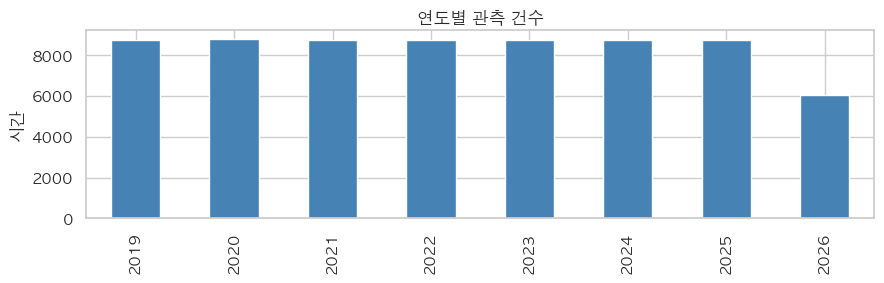

In [2]:
full = pd.date_range(m.obs_time.min(), m.obs_time.max(), freq="h")
missing_hours = full.difference(m.obs_time)
print(f"이론상 {len(full):,}시간 / 실제 {len(m):,}행 / 결손 {len(missing_hours):,}시간 "
      f"({len(missing_hours) / len(full) * 100:.2f}%)")

by_year = m.obs_time.dt.year.value_counts().sort_index()
ax = by_year.plot.bar(figsize=(9, 3), color="steelblue")
ax.set(title="연도별 관측 건수", xlabel="", ylabel="시간")
plt.tight_layout()

In [3]:
# 결손이 특정 날짜에 몰려 있는지 본다
gaps = pd.Series(missing_hours).dt.date.value_counts()
print(f"결손이 발생한 날: {len(gaps)}일")
print(gaps.head(10).to_string())

결손이 발생한 날: 93일
2026-02-08    10
2026-09-07     8
2026-07-22     5
2025-08-28     5
2024-06-17     4
2022-07-23     4
2021-03-30     3
2024-06-19     3
2020-04-07     2
2020-04-03     2


결손률 0.2% 수준이고 특정 날짜에 몰려 있다. 항공편과 시간 단위로 JOIN 할 때
그 날짜만 기상이 NaN 이 된다 — 실제로 2026-09-07 새벽이 그렇다.

## 2. 결측 구조 — 채워야 할 결측과 채우면 안 되는 결측

`gust_ms`·`cloud_base_ft`·`cloud_cover` 의 결측률이 높다. 고장이 아니다.

gust_ms           96.20
cloud_base_ft     50.40
cloud_cover       45.60
visibility_km      0.00
dewpoint_spread    0.00
dewpoint_c         0.00
temp_c             0.00
wind_dir           0.00
wind_ms            0.00


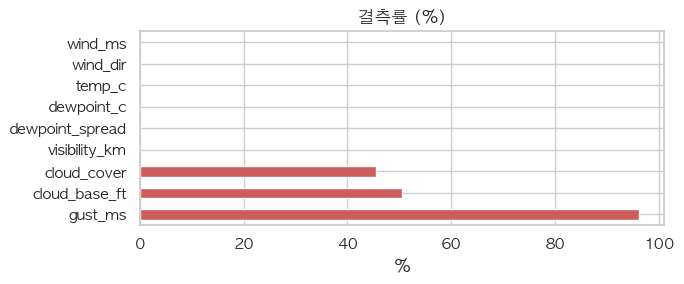

In [4]:
na = (m.isna().mean() * 100).sort_values(ascending=False)
na = na[na > 0]
ax = na.plot.barh(figsize=(7, 3), color="indianred")
ax.set(title="결측률 (%)", xlabel="%")
plt.tight_layout()
print(na.round(1).to_string())

In [5]:
# gust 는 '돌풍이 관측될 때만' 기록된다. 결측 = 돌풍 없음.
print("돌풍 기록이 있는 시간의 풍속 vs 없는 시간의 풍속")
print(m.groupby(m.gust_ms.isna())["wind_ms"].describe()[["count", "mean", "max"]].rename(
    index={True: "gust 결측", False: "gust 기록됨"}).round(2).to_string())

돌풍 기록이 있는 시간의 풍속 vs 없는 시간의 풍속
             count  mean   max
gust_ms                       
gust 기록됨  2,559.00  6.69 30.35
gust 결측  64,747.00  3.12 12.86


돌풍이 기록된 시간은 평균 풍속 자체가 뚜렷하게 높다. 즉 **결측은 "약풍이라 돌풍이 없었다"**
는 정보다. 0 으로 채우면 "돌풍 0m/s" 와 "돌풍 없음" 이 섞이고, 평균으로 채우면 거짓말이 된다.

XGBoost 는 NaN 을 분기 방향으로 직접 학습하므로 **그대로 두는 것이 맞다.**
`cloud_cover` 의 결측(구름 없음)·`NSC`(유의미한 구름 없음)도 같은 성격이다.

In [6]:
print(m.cloud_cover.value_counts(dropna=False).to_string())

cloud_cover
None    30672
FEW     19261
SCT      8007
BKN      5994
NSC      3271
OVC        92
CLR        10


## 3. 죽은 변수 — `precip_mm`

강수량은 지연 예측에 가장 쓰고 싶은 변수다. 그런데—

In [7]:
print(m.precip_mm.describe().to_string())
print("\n0 이 아닌 값의 개수:", (m.precip_mm > 0).sum())
print("비(RA)가 관측된 시간에도 강수량은:",
      m.loc[m.wx_ra == 1, "precip_mm"].unique())

count   67,307.00
mean         0.00
std          0.00
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          0.00

0 이 아닌 값의 개수: 0
비(RA)가 관측된 시간에도 강수량은: [0.]


**비가 온 5,538시간에도 강수량이 전부 0 이다.** RKPK 는 아카이브에 시간당 강수량(`p01i`)을
보고하지 않고 항상 `0.00` 을 채워 넣는다. 상수 컬럼이므로 **피처에서 제외한다.**

강수의 유무는 `wx_ra`(현상 코드)로만 알 수 있고, **강도는 알 수 없다.**
"폭우 vs 이슬비" 구분이 불가능하다는 뜻이라 모델 한계로 보고서에 적어야 한다.

## 4. 악기상 빈도와 계절성 — 이 프로젝트의 최대 제약

지연을 일으키는 건 평범한 날씨가 아니라 악기상이다. 얼마나 자주 오나?

착빙   0.00
눈    0.04
뇌전   0.19
안개   0.19
박무   4.48
비    8.23


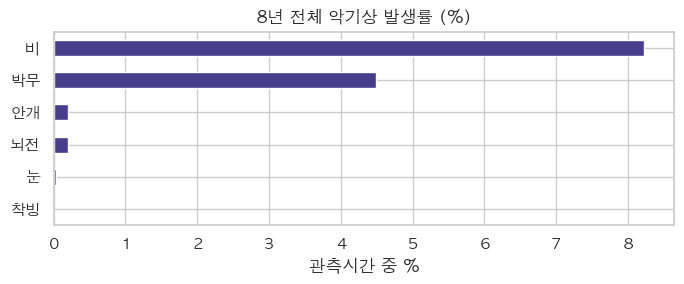

In [8]:
wx = [col for col in m.columns if col.startswith("wx_")]
label = {"wx_ts": "뇌전", "wx_fg": "안개", "wx_sn": "눈",
         "wx_fz": "착빙", "wx_ra": "비", "wx_br": "박무"}

overall = (m[wx].mean() * 100).rename(label).sort_values()
ax = overall.plot.barh(figsize=(7, 3), color="darkslateblue")
ax.set(title="8년 전체 악기상 발생률 (%)", xlabel="관측시간 중 %")
plt.tight_layout()
print(overall.round(2).to_string())

,뇌전,안개,눈,착빙,비,박무
month,,,,,,
1,0.03,0.20,0.22,0.00,4.73,2.39
2,0.00,0.37,0.06,0.00,6.47,2.11
3,0.05,0.39,0.03,0.00,8.48,4.76
4,0.05,0.16,0.00,0.00,8.32,4.30
5,0.15,0.13,0.00,0.00,9.26,5.99
6,0.21,0.19,0.00,0.00,12.30,7.25
7,0.61,0.42,0.00,0.00,13.17,10.04
8,0.51,0.13,0.00,0.00,10.66,5.52
9,0.48,0.11,0.00,0.00,11.58,5.01


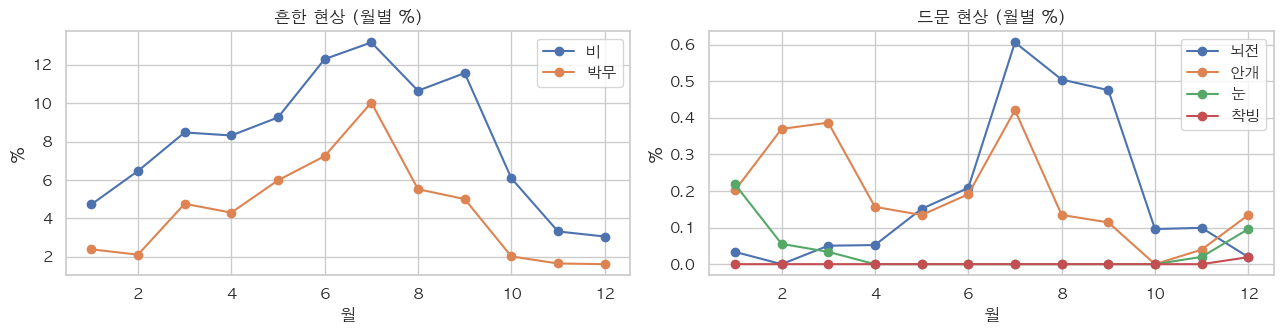

In [9]:
monthly = (m.groupby("month")[wx].mean() * 100).rename(columns=label)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
monthly[["비", "박무"]].plot(ax=axes[0], marker="o")
axes[0].set(title="흔한 현상 (월별 %)", xlabel="월", ylabel="%")
monthly[["뇌전", "안개", "눈", "착빙"]].plot(ax=axes[1], marker="o")
axes[1].set(title="드문 현상 (월별 %)", xlabel="월", ylabel="%")
plt.tight_layout()
monthly.round(2)

계절이 뚜렷하게 갈린다. 뇌전은 여름(7월 0.61%), 눈은 겨울(1월 0.22%), 비는 장마철(7월 13%).

문제는 **우리가 수집하는 구간이 9~12월** 이라는 점이다. 8년치로 그 구간만 떼어
4개월간 몇 시간이나 나올지 계산한다.

In [10]:
season = m[m.month.isin([9, 10, 11, 12])]
per_year = len(season) / m.obs_time.dt.year.nunique()

expect = pd.DataFrame({
    "9~12월 발생률(%)": (season[wx].mean() * 100).round(3),
    "4개월간 예상 시간": (season[wx].mean() * per_year).round(1),
}).rename(index=label).sort_values("4개월간 예상 시간", ascending=False)
expect

,9~12월 발생률(%),4개월간 예상 시간
비,6.05,156.40
박무,2.59,66.90
뇌전,0.17,4.50
안개,0.07,1.90
눈,0.03,0.80
착빙,0.01,0.10


**뇌전 약 5시간, 안개 2시간, 눈 1시간, 착빙 0시간.**

항공편은 하루 200편 남짓이고 그 중 도착 확정편은 ~130편이다.
안개가 낀 2시간에 걸리는 항공편은 많아야 10편 안팎 — **학습 표본이 사실상 없다.**

즉 `wx_ts`·`wx_fg`·`wx_sn`·`wx_fz` 네 개는 이번 수집 기간에 거의 전부 0 인 상수에 가깝고,
모델이 배울 것이 없다. 실질적으로 쓸 수 있는 기상 피처는 다음뿐이다.

| 쓸 수 있음 | 이유 |
|---|---|
| `wx_ra` · `wx_br` | 9~12월에도 각각 156시간 · 67시간 발생 |
| `visibility_km` | 연속값이라 악기상 코드 없이도 저시정을 표현 |
| `wind_ms` · `gust_ms` | 9월 태풍철에 돌풍 평균이 뚜렷하게 높다 |
| `cloud_base_ft` | 운고가 낮으면 착륙 제한 |

**보고서에 반드시 쓸 것:** 기상 변수의 설명력이 낮게 나오더라도 그것은 모델의 실패가 아니라
*"관측 기간에 악기상이 없었다"* 는 표본의 한계다.

## 5. 연속 변수 — 분포와 계절성

In [11]:
num = ["temp_c", "dewpoint_spread", "wind_ms", "gust_ms", "visibility_km", "cloud_base_ft"]
m[num].describe().round(2)

,temp_c,dewpoint_spread,wind_ms,gust_ms,visibility_km,cloud_base_ft
count,"67,299.00","67,299.00","67,306.00","2,559.00","67,284.00","33,354.00"
mean,15.49,7.74,3.26,11.95,9.48,"2,776.03"
std,9.61,5.71,2.00,2.89,1.47,"1,337.82"
min,-13.00,0.00,0.00,6.69,0.10,0.00
25%,8.00,3.00,1.54,10.29,9.99,"1,500.00"
50%,16.00,6.00,3.09,11.32,9.99,"3,000.00"
75%,24.00,11.00,4.63,12.86,9.99,"4,000.00"
max,39.00,42.00,30.35,38.58,9.99,"20,000.00"


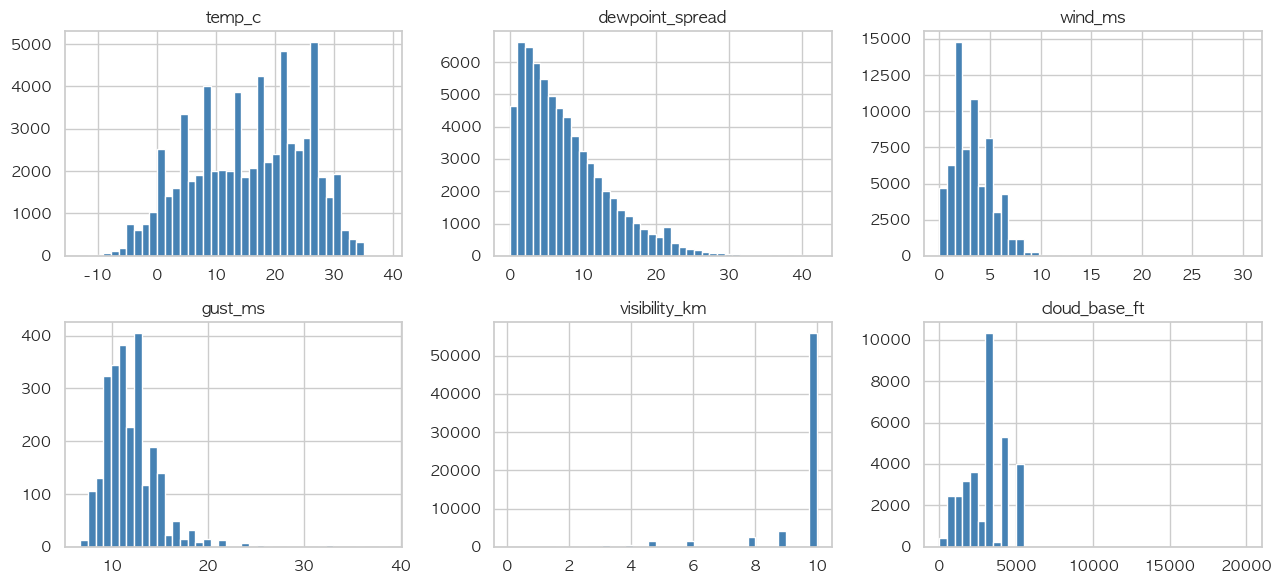

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), num):
    m[col].dropna().plot.hist(ax=ax, bins=40, color="steelblue")
    ax.set(title=col, ylabel="")
plt.tight_layout()

`visibility_km` 이 최댓값(약 10km)에 심하게 몰려 있다. METAR 는 10km 이상을 모두
10km 로 보고하기 때문이다. **저시정 구간에서만 변별력이 있는 변수**로 봐야 한다.

시정 5km 미만: 3,178시간 (4.72%)
시정 1.6km 미만: 399시간


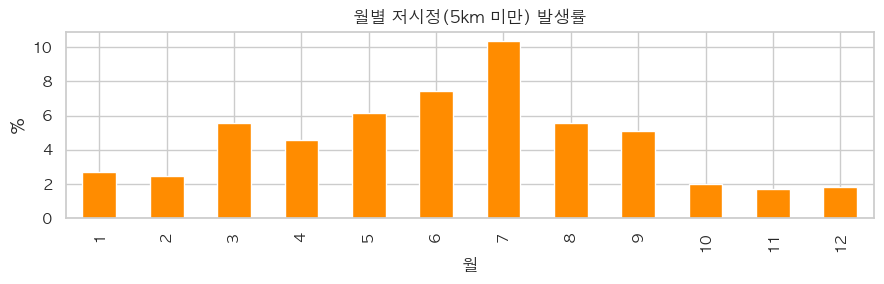

In [13]:
low = m[m.visibility_km < 5]
print(f"시정 5km 미만: {len(low):,}시간 ({len(low) / len(m) * 100:.2f}%)")
print(f"시정 1.6km 미만: {(m.visibility_km < 1.6).sum():,}시간")
ax = (m.groupby("month")["visibility_km"].apply(lambda s: (s < 5).mean() * 100)).plot.bar(
    figsize=(9, 3), color="darkorange")
ax.set(title="월별 저시정(5km 미만) 발생률", xlabel="월", ylabel="%")
plt.tight_layout()

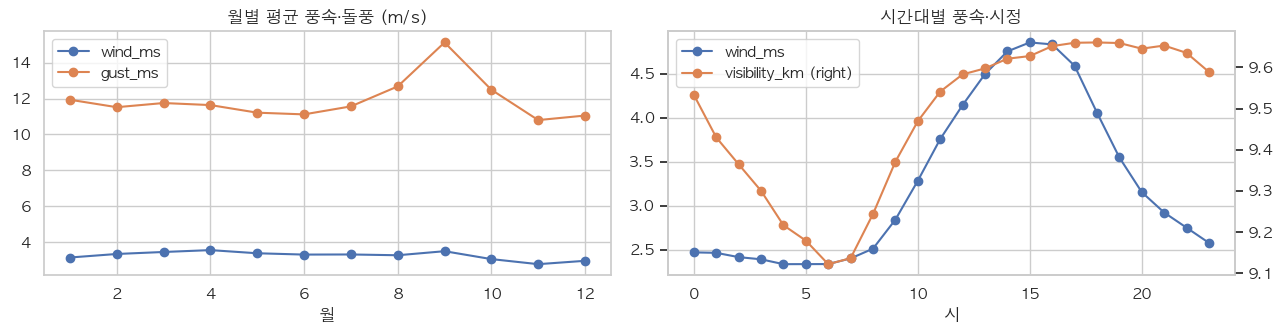

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
m.groupby("month")[["wind_ms", "gust_ms"]].mean().plot(ax=axes[0], marker="o")
axes[0].set(title="월별 평균 풍속·돌풍 (m/s)", xlabel="월")
m.groupby("hour")[["wind_ms", "visibility_km"]].mean().plot(
    ax=axes[1], marker="o", secondary_y="visibility_km")
axes[1].set(title="시간대별 풍속·시정", xlabel="시")
plt.tight_layout()

9월 돌풍 평균이 15.1 m/s 로 연중 최고다(태풍철). 수집 구간 첫 달이 여기 걸린다 —
**9월 데이터가 기상 변동의 대부분을 담당할 가능성이 높다.**

새벽에 시정이 낮아지는 일중 패턴도 보인다. 시간대(`hour`) 피처가 기상을 일부 대리한다는 뜻이라,
모델에서 기상 변수의 기여를 볼 때 `hour` 와 섞이지 않는지 주의해야 한다.

## 6. 상관 — 기상 변수끼리 얼마나 겹치나

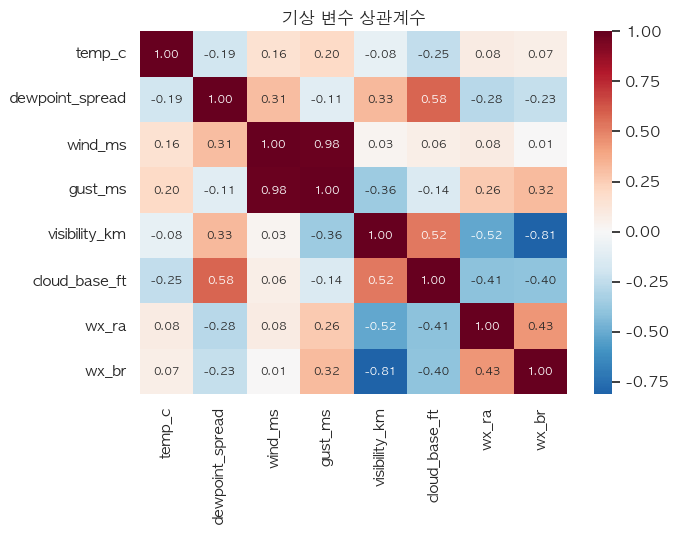

In [15]:
corr = m[num + ["wx_ra", "wx_br"]].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size": 8})
ax.set_title("기상 변수 상관계수")
plt.tight_layout()

`dewpoint_spread` 와 `visibility_km`·`wx_br` 이 함께 움직인다 — 기온과 이슬점이 붙으면
박무·저시정이 온다는 물리를 그대로 보여준다. 안개 위험 대리 변수로서 의도대로 작동한다.

## 정리 — 모델링에 반영할 것

1. **`precip_mm` 제외** — 상수 0. 강수 강도는 관측 불가.
2. **결측을 채우지 않는다** — `gust_ms`·`cloud_cover` 의 NaN 은 "해당 없음"이라는 정보다.
3. **`wx_fz`·`wx_sn`·`wx_ts`·`wx_fg` 는 기대하지 않는다** — 9~12월 예상 표본이 한 자릿수 시간.
4. **주력 기상 피처는 `wx_ra`·`wx_br`·`visibility_km`·`wind_ms`·`gust_ms`·`cloud_base_ft`.**
5. **`hour` 와 기상이 교란된다** — 새벽 저시정 패턴. 피처 중요도 해석 시 주의.